# Spatial aggregation

Aggregate raster or vector data.

**_raster:_** Creates a new raster with a lower resolution (larger cells), with the values for the resulting cells is computed with a user-specified function.

**_vector:_** "Dissolves" to either combine all geometries into one geometry, or combine the geometries that have the same value for the variable(s) specified with argument `by`.

## Settings

In [6]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Parameters
param_factor <- 2
param_function <- "mean" # or: "max", "min", "median", "sum", "modal", "any", "all", "prod", "which.min", "which.max", "table", "sd" 
param_group <- "ID_1"
param_out <- tempdir()

# Paths for examples
in_raster <- system.file("ex/elev.tif", package = "terra")
in_vector <- system.file("ex/lux.shp", package = "terra")

## Aggregate raster

In [11]:
# GSTB aggregate raster
# NaaVRE:
#  cell:
#   inputs:
#    - in_raster: String
#   params:
#    - param_factor: Integer
#    - param_function: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Aggregate raster
aggregate(x         = rast(in_raster),
          fact      = param_factor,
          fun       = param_function,
          filename  = paste0(param_out, "/aggregated_raster.tif"),
          overwrite = TRUE,
          count     = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "aggregated_raster.tif",
                  full.names = TRUE)

class       : SpatRaster 
dimensions  : 45, 48, 1  (nrow, ncol, nlyr)
resolution  : 0.01666667, 0.01666667  (x, y)
extent      : 5.741667, 6.541667, 49.44167, 50.19167  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : aggregated_raster.tif 
name        : elevation 
min value   :    166.75 
max value   :    529.50 

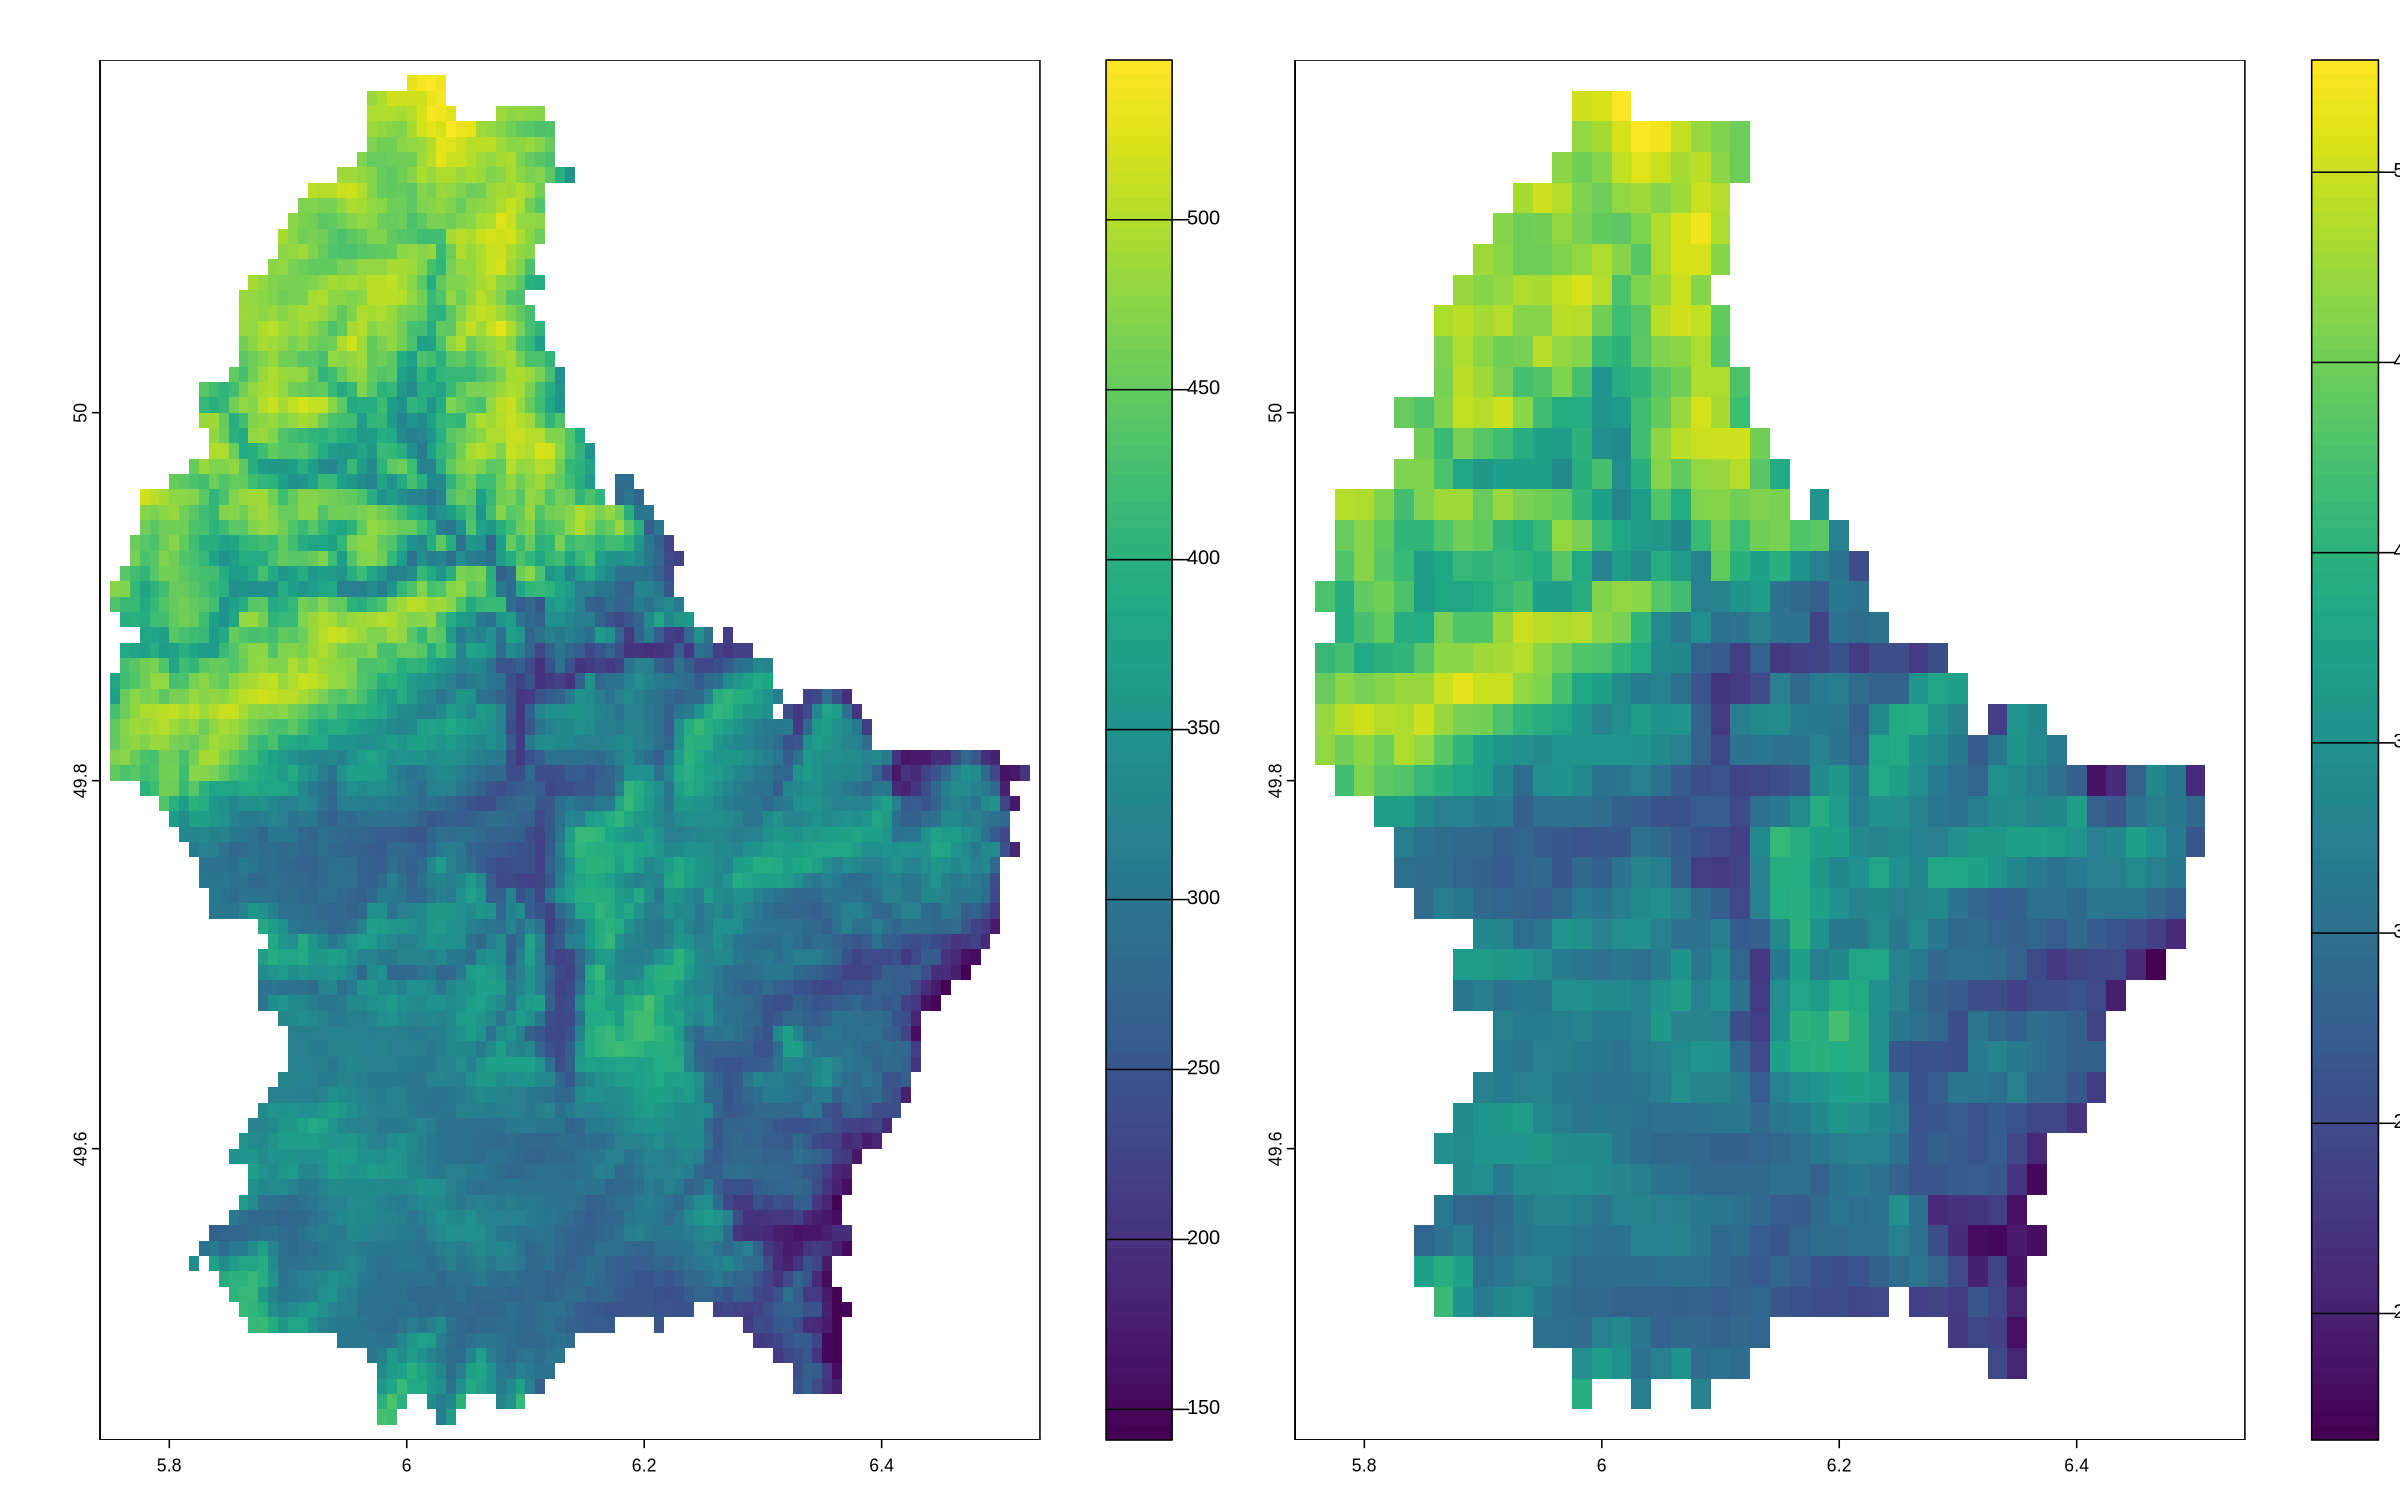

In [12]:
options(repr.plot.width = 16,
        repr.plot.height = 10,
        repr.plot.res = 150)
par(mfrow = c(1, 2))
plot(x)
plot(rast(out))
par(mfrow = c(1, 1))

## Aggregate vector

In [14]:
# GSTB aggregate vector
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#   params:
#    - param_group: String
#    - param_function: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...
 
# Aggregate vector
writeVector(x         = aggregate(x        = vect(in_vector),
                                  by       = param_group,
                                  dissolve = TRUE, 
                                  fun      = param_function,
                                  count    = TRUE),
            filename  = paste0(param_out, "/aggregated_vector.gpkg"),
            overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "aggregated_vector.gpkg",
                  full.names = TRUE)

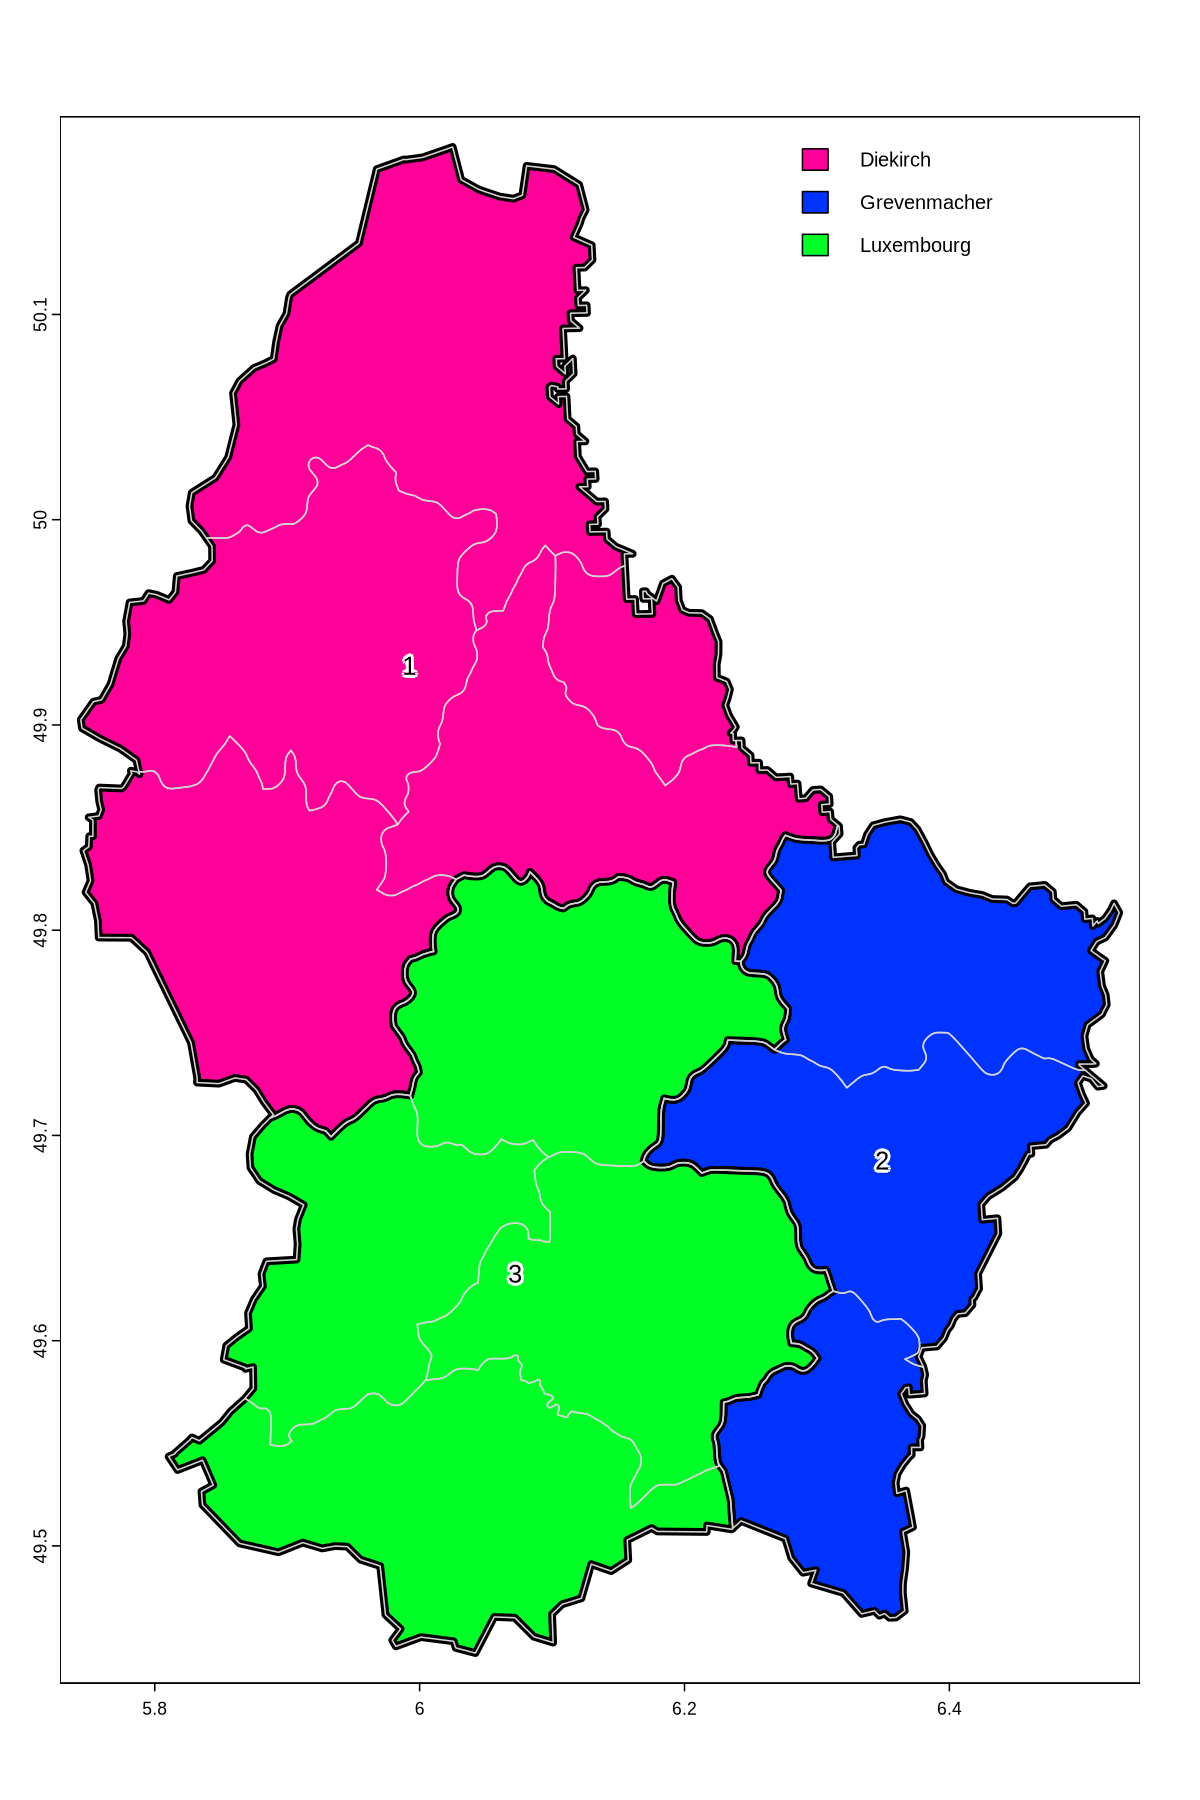

In [16]:
options(repr.plot.width = 8,
        repr.plot.height = 12,
        repr.plot.res = 150)
plot(vect(out), "NAME_1",
     lwd = 5, mar = rep(2, 4),
     plg = list(x = "topright"))
lines(x, lwd = 1,
      col = "light gray")
text(v, "ID_1",
     halo = TRUE)